# Late Fusion Pipeline

This notebook implements late fusion by combining predictions from pre-trained unimodal models (audio and tapping). The approach:
1. Load separate pre-trained models for audio and tapping modalities
2. Generate predictions from each model independently
3. Combine predictions using various fusion strategies:
   - Weighted average on probabilities
   - Weighted average on predicted labels
   - Majority voting

Late fusion allows each modality to be optimized independently before combining their outputs.

## 1. Imports

In [21]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sys
import os
import torch
from sklearn.metrics import roc_auc_score, f1_score, accuracy_score, confusion_matrix
from scipy import stats

sys.path.append(os.path.abspath(".."))

# EarlyFusion models
from FusionModels.LateFusionMLP import *
from FusionModels.utils import evaluate_models_on_test_folds

## 2. Data Loading & Preparation

Prepare the data for evaluation by splitting it into separate ID and feature files. This separation is necessary for the late fusion pipeline to properly match predictions with patient identifiers.

### 2.1 Tapping Features Preparation

Split the tapping features CSV into:
- **IDs file**: Contains index, healthCode, and trial_id for matching
- **Features file**: Contains only the numerical features for model input

In [ ]:
TAPPING_FEATURES = "/mloscratch/users/clerget/data/csv/tapping_combined_features_session.csv"

# Read the tapping features CSV
tapping_df = pd.read_csv(TAPPING_FEATURES)

# Add index column to preserve order
tapping_df['index'] = range(len(tapping_df))

# Split into two dataframes
tapping_ids = tapping_df[['index', 'healthCode', 'trial_id']]
tapping_features = tapping_df.drop(columns=['healthCode', 'trial_id'])

# Save to src_GAMMA directory
output_path = "/tremor2tensor/src_GAMMA/"
ids_path = os.path.join(output_path, "tapping_ids.csv")
features_path = os.path.join(output_path, "tapping_features.csv")

tapping_ids.to_csv(ids_path, index=False)
tapping_features.to_csv(features_path, index=False)

print(f"Saved tapping_ids.csv: shape {tapping_ids.shape}")
print(f"Saved tapping_features.csv: shape {tapping_features.shape}")
print(f"\nSample of tapping_ids:\n{tapping_ids.head()}")
print(f"\nSample of tapping_features:\n{tapping_features.head()}")

Saved tapping_ids.csv: shape (15765, 3)
Saved tapping_features.csv: shape (15765, 14)

Sample of tapping_ids:
   index                            healthCode  \
0      0  5134777c-3563-41a5-abcf-cce272a2ebf3   
1      1  3516da76-a3e1-47ac-9255-ee100797ba9b   
2      2  0a4662b0-9ee3-4029-af85-7e342cb87810   
3      3  e787d06a-bcce-4ef0-848e-8b319fc7ce99   
4      4  3516da76-a3e1-47ac-9255-ee100797ba9b   

                               trial_id  
0  0569fa9a-1a93-4d59-b85d-40c517972401  
1  57669af2-0c19-4da5-8f0c-efbb52d95700  
2  8f724f33-755b-463d-be3c-28c3f94a929b  
3  3de7554a-0c34-4f6a-a4b1-5f7c19c58ca5  
4  a213575e-2161-4d44-a8db-322b43b70722  

Sample of tapping_features:
    mean_dt    std_dt  total_taps      mean_x      mean_y      std_x  \
0  0.131566  0.115565         152  143.362745  434.088235  73.065760   
1  0.080679  0.081303         247  151.334677  400.203629  60.303491   
2  0.181918  0.114110         108  153.674312  405.220183  78.037640   
3  0.197994  0.12245

### 2.2 Audio Features Preparation

Split the audio features CSV into:
- **IDs file**: Contains index, filename, healthCode, and record_id for matching
- **Features file**: Contains only the numerical acoustic features for model input

In [ ]:
AUDIO_FEATURES = "/mloscratch/users/gnahas/data/features/acoustic_features_vf.csv"

# Read the audio features CSV
audio_df = pd.read_csv(AUDIO_FEATURES)

# Rename healthcode to healthCode
audio_df = audio_df.rename(columns={'healthcode': 'healthCode'})

# Add index column to preserve order
audio_df['index'] = range(len(audio_df))

# Split into two dataframes
audio_ids = audio_df[['index', 'filename', 'healthCode', 'record_id']]
audio_features = audio_df.drop(columns=['filename', 'healthCode', 'record_id'])

# Save to src_GAMMA directory
output_path = "/tremor2tensor/src_GAMMA/"
ids_path = os.path.join(output_path, "audio_ids.csv")
features_path = os.path.join(output_path, "audio_features.csv")

audio_ids.to_csv(ids_path, index=False)
audio_features.to_csv(features_path, index=False)

print(f"Saved audio_ids.csv: shape {audio_ids.shape}")
print(f"Saved audio_features.csv: shape {audio_features.shape}")
print(f"\nSample of audio_ids:\n{audio_ids.head()}")
print(f"\nSample of audio_features:\n{audio_features.head()}")

Saved audio_ids.csv: shape (14948, 4)
Saved audio_features.csv: shape (14948, 155)

Sample of audio_ids:
   index                                           filename  \
0      0  00081bd9-9abd-4003-b035-de6cc3e8c922_f5f9fe7a-...   
1      1  0160664a-f4af-4071-a4aa-2967f3ea0503_04de04ab-...   
2      2  0160664a-f4af-4071-a4aa-2967f3ea0503_07694dc8-...   
3      3  0160664a-f4af-4071-a4aa-2967f3ea0503_0c466425-...   
4      4  0160664a-f4af-4071-a4aa-2967f3ea0503_128091f2-...   

                             healthCode                             record_id  
0  00081bd9-9abd-4003-b035-de6cc3e8c922  f5f9fe7a-16ea-4729-ad36-4adf16d640d3  
1  0160664a-f4af-4071-a4aa-2967f3ea0503  04de04ab-34b7-45ce-9cb5-59465eb51602  
2  0160664a-f4af-4071-a4aa-2967f3ea0503  07694dc8-0fe3-434c-a3a7-4d981d0a435b  
3  0160664a-f4af-4071-a4aa-2967f3ea0503  0c466425-cd90-468d-ac9a-cf9d322a4729  
4  0160664a-f4af-4071-a4aa-2967f3ea0503  128091f2-7350-4f48-99fe-c99137e6c94d  

Sample of audio_features:
   mfcc_1

### 2.3 Global Path Configuration

Define the paths to all necessary data files:
- Feature and ID files for both modalities
- Patient labels
- Cross-validation fold assignments

In [ ]:
TAPPING_FEATURES = "/tremor2tensor/src_GAMMA/tapping_features.csv"
TAPPING_IDS = "/tremor2tensor/src_GAMMA/tapping_ids.csv"
AUDIO_FEATURES = "/tremor2tensor/src_GAMMA/audio_features.csv"
AUDIO_IDS = "/tremor2tensor/src_GAMMA/audio_ids.csv"
LABELS = "/tremor2tensor/src_GAMMA/paired_healthcode.csv"
VAL_TEST_FOLDS = "/tremor2tensor/src_GAMMA/5_fold_CV/processed_paired/paired_splits/balanced_train/healthcode_5fold_val_test.csv"


## 3. Loading & Running Pre-trained Unimodal Models

### 3.1 Tapping Features MLP 

Load and evaluate pre-trained tapping models (one for each of the 5 folds). These models were previously trained using hyperparameter optimization on tapping features alone.

In [25]:
FOLD_0_PTH = "/mloscratch/users/clerget/data/saved_models/best_model_hp135_fold0.pth"
FOLD_1_PTH = "/mloscratch/users/clerget/data/saved_models/best_model_hp135_fold1.pth"
FOLD_2_PTH = "/mloscratch/users/clerget/data/saved_models/best_model_hp135_fold2.pth"
FOLD_3_PTH = "/mloscratch/users/clerget/data/saved_models/best_model_hp135_fold3.pth"
FOLD_4_PTH = "/mloscratch/users/clerget/data/saved_models/best_model_hp135_fold4.pth"

In [26]:
INPUT_DIM = 13
LEARNING_RATE = 0.0005
WEIGHT_DECAY = 0.005
DROPOUT = 0.2
HIDDEN_DIMENSION_1 = 32
HIDDEN_DIMENSION_2 = 16

#### Model Architecture Configuration

Define the hyperparameters for the pre-trained tapping MLP:
- Input dimension: 13 tapping features
- Hidden layers: 32 → 16 neurons
- Dropout rate: 0.2
- Learning rate and weight decay match the original training configuration

In [27]:
# Set device to CUDA if available
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

# Initialize the 5 models (one for each fold)
models = []
model_paths = [FOLD_0_PTH, FOLD_1_PTH, FOLD_2_PTH, FOLD_3_PTH, FOLD_4_PTH]

for fold_idx, model_path in enumerate(model_paths):
    # Create model instance with the best hyperparameters
    model = MLP(
        input_dim=INPUT_DIM,
        hidden_dim_1=HIDDEN_DIMENSION_1,
        hidden_dim_2=HIDDEN_DIMENSION_2,
        dropout_rate=DROPOUT
    )
    
    # Load the saved state dict
    state_dict = torch.load(model_path, map_location=device)
    model.load_state_dict(state_dict)
    
    # Move model to device and set to evaluation mode
    model.to(device)
    model.eval()
    
    models.append(model)
    print(f"Fold {fold_idx} model loaded successfully from {model_path}")

print(f"\nAll {len(models)} models reconstructed and ready for forward passes!")

# Test with a dummy input to verify
with torch.no_grad():
    dummy_input = torch.randn(1, INPUT_DIM).to(device)
    test_output = models[0](dummy_input)
    print(f"\nTest forward pass output shape: {test_output.shape}")
    print(f"Test forward pass output: {test_output}")


Using device: cuda
Fold 0 model loaded successfully from /mloscratch/users/clerget/data/saved_models/best_model_hp135_fold0.pth
Fold 1 model loaded successfully from /mloscratch/users/clerget/data/saved_models/best_model_hp135_fold1.pth
Fold 2 model loaded successfully from /mloscratch/users/clerget/data/saved_models/best_model_hp135_fold2.pth
Fold 3 model loaded successfully from /mloscratch/users/clerget/data/saved_models/best_model_hp135_fold3.pth
Fold 4 model loaded successfully from /mloscratch/users/clerget/data/saved_models/best_model_hp135_fold4.pth

All 5 models reconstructed and ready for forward passes!

Test forward pass output shape: torch.Size([1, 2])
Test forward pass output: tensor([[-1.0344,  0.9173]], device='cuda:0')


#### Load Pre-trained Models

Reconstruct and load the 5 tapping models (one per fold) from saved weights.

In [28]:
# Load the dataframes
tapping_features_df = pd.read_csv(TAPPING_FEATURES)
tapping_ids_df = pd.read_csv(TAPPING_IDS)
labels_df = pd.read_csv(LABELS)

# Evaluate the models on the test folds
tapping_test_results = evaluate_models_on_test_folds(
    models=models,
    features_df=tapping_features_df,
    ids_df=tapping_ids_df,    
    device=device,
    labels_df=labels_df,    
    val_test_folds_csv=VAL_TEST_FOLDS)

print(f"\nResults summary by fold:")
print(tapping_test_results.head(10))

Processing fold 0...
Processing fold 1...
Processing fold 2...
Processing fold 3...
Processing fold 4...
Total predictions: 15765
Results shape: (15765, 5)

Results summary by fold:
                             healthCode  logits_0  logits_1  actual_label  \
0  b5d300e5-4397-4f24-ab97-6ae76a3c956b -1.054760  0.935638             1   
1  7808370a-fa5a-4383-919c-f5d9ae45165a  0.526837 -0.490225             0   
2  702bc6dd-423f-4416-ae41-deded2e81ed7  1.227446 -1.123753             1   
3  5ce69643-aeec-44e5-a5cc-4c06d36f5979 -0.402626  0.348208             1   
4  9850af88-fdd6-4fe8-8859-24cc2542d135 -1.381755  1.231445             1   
5  7808ea07-7623-4c0d-97a0-ce8c66e79274  0.822607 -0.758805             0   
6  5ce69643-aeec-44e5-a5cc-4c06d36f5979 -0.171683  0.139478             1   
7  b5d300e5-4397-4f24-ab97-6ae76a3c956b -1.508555  1.346780             1   
8  b5d300e5-4397-4f24-ab97-6ae76a3c956b -0.669534  0.588117             1   
9  43294479-32e0-4589-92ee-269b36a70e46 -0.21847

#### Evaluate on Test Folds

Generate predictions from each model on its corresponding test fold. Results include:
- Logits for both classes
- healthCode and fold information
- Actual labels for computing metrics

In [29]:
# Compute probabilities from logits
logits = torch.tensor(tapping_test_results[['logits_0', 'logits_1']].values)
proba = torch.softmax(logits, dim=1)
proba_class_1 = proba[:, 1].numpy()

# Compute ROC AUC per fold BEFORE modifying the dataframe
roc_aucs = []
for fold in range(5):
    fold_mask = tapping_test_results['fold'] == fold
    fold_labels = tapping_test_results.loc[fold_mask, 'actual_label'].values
    fold_proba = proba_class_1[fold_mask]
    
    if len(fold_labels) > 0:
        roc_auc = roc_auc_score(fold_labels, fold_proba)
        roc_aucs.append(roc_auc)
        print(f"Fold {fold} ROC AUC: {roc_auc:.4f}")

# Compute overall statistics
mean_roc_auc = np.mean(roc_aucs)
std_roc_auc = np.std(roc_aucs)
print(f"\n**Tapping Mean ROC AUC: {mean_roc_auc:.4f} ± {std_roc_auc:.4f}**")

# Now add probabilities and predictions to results
tapping_test_results['proba_class_1'] = proba_class_1
tapping_test_results['predicted_label'] = np.where(proba_class_1 >= 0.5, 1, 0).astype(int)

# Print counts of predicted labels
counts = tapping_test_results['predicted_label'].value_counts().sort_index()
zeros = int(counts.get(0, 0))
ones = int(counts.get(1, 0))
print(f"\nTapping predicted_label counts -> 0s: {zeros}, 1s: {ones}")

# Compute F1 score and accuracy per fold
f1_scores = []
accuracies = []
for fold in range(5):
    fold_mask = tapping_test_results['fold'] == fold
    fold_labels = tapping_test_results.loc[fold_mask, 'actual_label'].values
    fold_preds = tapping_test_results.loc[fold_mask, 'predicted_label'].values
    
    if len(fold_labels) > 0:
        f1 = f1_score(fold_labels, fold_preds)
        acc = accuracy_score(fold_labels, fold_preds)
        f1_scores.append(f1)
        accuracies.append(acc)
        print(f"Fold {fold} F1: {f1:.4f}, Accuracy: {acc:.4f}")

# Compute overall statistics
mean_f1 = np.mean(f1_scores)
std_f1 = np.std(f1_scores)
mean_acc = np.mean(accuracies)
std_acc = np.std(accuracies)
print(f"\n**Tapping Mean F1 Score: {mean_f1:.4f} ± {std_f1:.4f}**")
print(f"**Tapping Mean Accuracy: {mean_acc:.4f} ± {std_acc:.4f}**")

Fold 0 ROC AUC: 0.5960
Fold 1 ROC AUC: 0.6824
Fold 2 ROC AUC: 0.7474
Fold 3 ROC AUC: 0.6412
Fold 4 ROC AUC: 0.7056

**Tapping Mean ROC AUC: 0.6745 ± 0.0522**

Tapping predicted_label counts -> 0s: 6589, 1s: 9176
Fold 0 F1: 0.7085, Accuracy: 0.6019
Fold 1 F1: 0.7454, Accuracy: 0.6527
Fold 2 F1: 0.7183, Accuracy: 0.6378
Fold 3 F1: 0.7250, Accuracy: 0.6148
Fold 4 F1: 0.7469, Accuracy: 0.6391

**Tapping Mean F1 Score: 0.7288 ± 0.0151**
**Tapping Mean Accuracy: 0.6292 ± 0.0183**


#### Session-level Performance Metrics

Compute performance metrics on individual trials (sessions) before any aggregation:
- Convert logits to probabilities using softmax
- Compute ROC AUC, F1 score, and accuracy per fold
- Report mean and standard deviation across folds

This represents the baseline performance of the tapping model at the trial level.

#### Patient-level Performance (Averaged Probabilities)

Aggregate predictions at the patient level by averaging class probabilities across all trials for each healthCode. This provides a more stable patient-level prediction and computes patient-level ROC AUC.

In [30]:
# Create a copy to avoid affecting downstream processes
averaged_tapping_test_results = tapping_test_results.copy()

# Compute average proba_class_1 per healthCode and fold
averaged_tapping_test_results = averaged_tapping_test_results.groupby(['healthCode', 'fold']).agg({
    'proba_class_1': 'mean',  # Average probability across all trials for this healthCode
    'actual_label': 'first'   # Should be same for all records of a healthCode
}).reset_index()

print("Averaged Tapping Test Results (per HealthCode):")
print(f"Total unique healthCodes: {averaged_tapping_test_results['healthCode'].nunique()}")
print(f"Shape: {averaged_tapping_test_results.shape}\n")

# Compute ROC AUC per fold
roc_aucs_averaged = []
for fold in range(5):
    fold_mask = averaged_tapping_test_results['fold'] == fold
    fold_labels = averaged_tapping_test_results.loc[fold_mask, 'actual_label'].values
    fold_proba = averaged_tapping_test_results.loc[fold_mask, 'proba_class_1'].values
    
    if len(fold_labels) > 0:
        roc_auc = roc_auc_score(fold_labels, fold_proba)
        roc_aucs_averaged.append(roc_auc)
        print(f"Fold {fold} ROC AUC: {roc_auc:.4f}")

# Compute overall statistics
mean_roc_auc_averaged = np.mean(roc_aucs_averaged)
std_roc_auc_averaged = np.std(roc_aucs_averaged)
print(f"\n**Tapping (Averaged per HealthCode) Mean Test ROC AUC: {mean_roc_auc_averaged:.4f} ± {std_roc_auc_averaged:.4f}**")


Averaged Tapping Test Results (per HealthCode):
Total unique healthCodes: 532
Shape: (532, 4)

Fold 0 ROC AUC: 0.7099
Fold 1 ROC AUC: 0.7562
Fold 2 ROC AUC: 0.7822
Fold 3 ROC AUC: 0.6870
Fold 4 ROC AUC: 0.7511

**Tapping (Averaged per HealthCode) Mean Test ROC AUC: 0.7373 ± 0.0342**


#### Patient-level Performance (Majority Voting)

Alternative aggregation strategy using majority voting on predicted labels:
- Take the most common predicted label across all trials for each patient
- Compute confusion matrices and metrics per fold
- Visualize results with confusion matrix heatmaps

Tapping Majority Vote Results (per HealthCode):
Total unique healthCodes: 532
Shape: (532, 4)



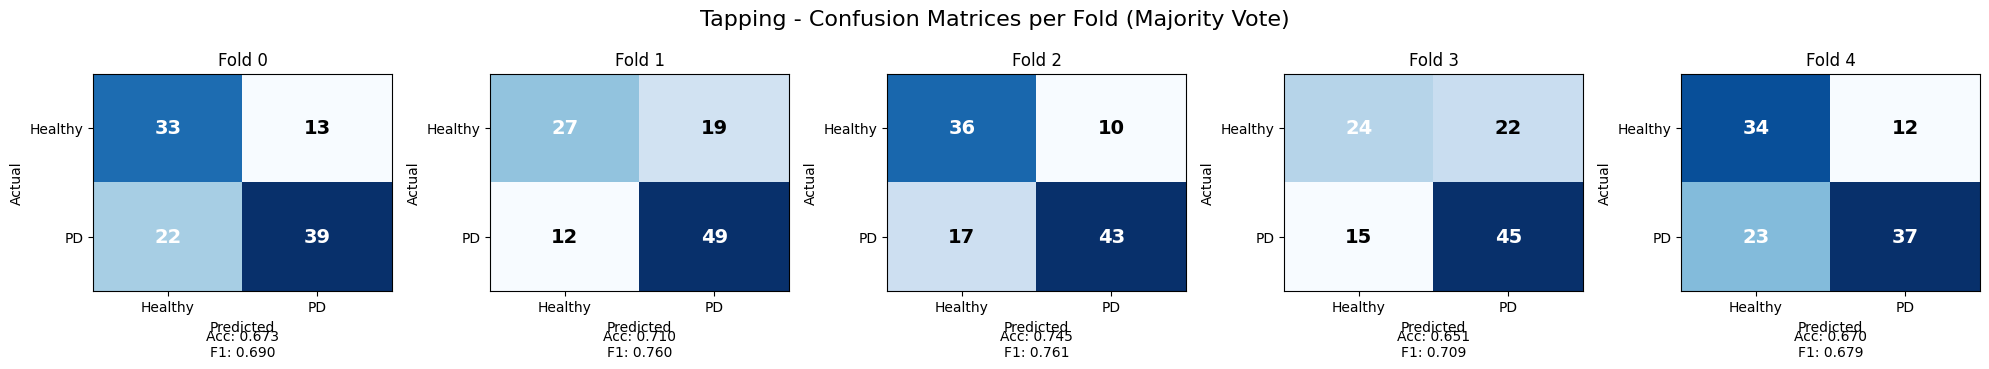


**Overall (Majority Vote) - Tapping:**
**Accuracy: 0.6898**
**F1 Score: 0.7208**


In [31]:
from sklearn.metrics import confusion_matrix
from scipy import stats

# Create a new dataframe with majority voting per healthCode
tapping_majority_vote = tapping_test_results.groupby(['healthCode', 'fold']).agg({
    'predicted_label': lambda x: stats.mode(x, keepdims=True)[0][0],  # Majority vote
    'actual_label': 'first'  # Should be same for all records of a healthCode
}).reset_index()

print("Tapping Majority Vote Results (per HealthCode):")
print(f"Total unique healthCodes: {tapping_majority_vote['healthCode'].nunique()}")
print(f"Shape: {tapping_majority_vote.shape}\n")

# Plot confusion matrices per fold
fig, axes = plt.subplots(1, 5, figsize=(20, 4))
fig.suptitle('Tapping - Confusion Matrices per Fold (Majority Vote)', fontsize=16)

for fold in range(5):
    fold_data = tapping_majority_vote[tapping_majority_vote['fold'] == fold]
    if len(fold_data) > 0:
        cm = confusion_matrix(fold_data['actual_label'], fold_data['predicted_label'])
        
        # Plot confusion matrix
        im = axes[fold].imshow(cm, cmap='Blues', aspect='auto')
        axes[fold].set_title(f'Fold {fold}')
        axes[fold].set_xlabel('Predicted')
        axes[fold].set_ylabel('Actual')
        axes[fold].set_xticks([0, 1])
        axes[fold].set_yticks([0, 1])
        axes[fold].set_xticklabels(['Healthy', 'PD'])
        axes[fold].set_yticklabels(['Healthy', 'PD'])
        
        # Add text annotations
        for i in range(2):
            for j in range(2):
                text = axes[fold].text(j, i, cm[i, j],
                                      ha="center", va="center", color="white" if cm[i, j] > cm.max()/2 else "black",
                                      fontsize=14, weight='bold')
        
        # Compute metrics
        acc = accuracy_score(fold_data['actual_label'], fold_data['predicted_label'])
        f1 = f1_score(fold_data['actual_label'], fold_data['predicted_label'])
        axes[fold].text(0.5, -0.3, f'Acc: {acc:.3f}\nF1: {f1:.3f}', 
                       ha='center', transform=axes[fold].transAxes, fontsize=10)

plt.tight_layout()
plt.show()

# Overall statistics across folds
all_labels = tapping_majority_vote['actual_label'].values
all_preds = tapping_majority_vote['predicted_label'].values

overall_acc = accuracy_score(all_labels, all_preds)
overall_f1 = f1_score(all_labels, all_preds)

print(f"\n**Overall (Majority Vote) - Tapping:**")
print(f"**Accuracy: {overall_acc:.4f}**")
print(f"**F1 Score: {overall_f1:.4f}**")

### 3.2 Audio Features MLP 

Load and evaluate pre-trained audio models (one for each of the 5 folds). These models were previously trained using hyperparameter optimization on audio features alone.

In [32]:
FOLD_0_PTH = "/mloscratch/users/gnahas/NeuroMeditron/src_GAMMA/audio_model/Results/MLP_v2_HP_Search/undersampling_mean/PTH/best_model_hp92_fold0.pth"
FOLD_1_PTH = "/mloscratch/users/gnahas/NeuroMeditron/src_GAMMA/audio_model/Results/MLP_v2_HP_Search/undersampling_mean/PTH/best_model_hp92_fold1.pth"
FOLD_2_PTH = "/mloscratch/users/gnahas/NeuroMeditron/src_GAMMA/audio_model/Results/MLP_v2_HP_Search/undersampling_mean/PTH/best_model_hp92_fold2.pth"
FOLD_3_PTH = "/mloscratch/users/gnahas/NeuroMeditron/src_GAMMA/audio_model/Results/MLP_v2_HP_Search/undersampling_mean/PTH/best_model_hp92_fold3.pth"
FOLD_4_PTH = "/mloscratch/users/gnahas/NeuroMeditron/src_GAMMA/audio_model/Results/MLP_v2_HP_Search/undersampling_mean/PTH/best_model_hp92_fold4.pth"

In [33]:
INPUT_DIM = 154
LEARNING_RATE = 0.0005
WEIGHT_DECAY = 0.0001
DROPOUT = 0.5
HIDDEN_DIMENSION_1 = 32
HIDDEN_DIMENSION_2 = 64

#### Audio Model Architecture Configuration

Define the hyperparameters for the pre-trained audio MLP:
- Input dimension: 154 acoustic features
- Hidden layers: 32 → 64 neurons
- Dropout rate: 0.5
- Learning rate and weight decay match the original training configuration

In [34]:
# Reuse device if already defined; otherwise set it
try:
    device
except NameError:
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

# Initialize the 5 models (one for each fold) for Audio
audio_models = []
audio_model_paths = [FOLD_0_PTH, FOLD_1_PTH, FOLD_2_PTH, FOLD_3_PTH, FOLD_4_PTH]

for fold_idx, model_path in enumerate(audio_model_paths):
    # Create model instance with the best hyperparameters for audio
    audio_model = MLP(
        input_dim=INPUT_DIM,
        hidden_dim_1=HIDDEN_DIMENSION_1,
        hidden_dim_2=HIDDEN_DIMENSION_2,
        dropout_rate=DROPOUT
    )
    
    # Load the saved state dict
    state_dict = torch.load(model_path, map_location=device)
    audio_model.load_state_dict(state_dict)
    
    # Move model to device and set to evaluation mode
    audio_model.to(device)
    audio_model.eval()
    
    audio_models.append(audio_model)
    print(f"Audio Fold {fold_idx} model loaded successfully from {model_path}")

print(f"\nAll {len(audio_models)} audio models reconstructed and ready for forward passes!")

# Test with a dummy input to verify
with torch.no_grad():
    dummy_audio_input = torch.randn(1, INPUT_DIM).to(device)
    test_audio_output = audio_models[0](dummy_audio_input)
    print(f"\nAudio test forward pass output shape: {test_audio_output.shape}")
    print(f"Audio test forward pass output: {test_audio_output}")

Using device: cuda
Audio Fold 0 model loaded successfully from /mloscratch/users/gnahas/NeuroMeditron/src_GAMMA/audio_model/Results/MLP_v2_HP_Search/undersampling_mean/PTH/best_model_hp92_fold0.pth
Audio Fold 1 model loaded successfully from /mloscratch/users/gnahas/NeuroMeditron/src_GAMMA/audio_model/Results/MLP_v2_HP_Search/undersampling_mean/PTH/best_model_hp92_fold1.pth
Audio Fold 2 model loaded successfully from /mloscratch/users/gnahas/NeuroMeditron/src_GAMMA/audio_model/Results/MLP_v2_HP_Search/undersampling_mean/PTH/best_model_hp92_fold2.pth
Audio Fold 3 model loaded successfully from /mloscratch/users/gnahas/NeuroMeditron/src_GAMMA/audio_model/Results/MLP_v2_HP_Search/undersampling_mean/PTH/best_model_hp92_fold3.pth
Audio Fold 4 model loaded successfully from /mloscratch/users/gnahas/NeuroMeditron/src_GAMMA/audio_model/Results/MLP_v2_HP_Search/undersampling_mean/PTH/best_model_hp92_fold4.pth

All 5 audio models reconstructed and ready for forward passes!

Audio test forward pa

#### Load Pre-trained Audio Models

Reconstruct and load the 5 audio models (one per fold) from saved weights.

In [35]:
# Load the dataframes for Audio
audio_features_df = pd.read_csv(AUDIO_FEATURES)
audio_ids_df = pd.read_csv(AUDIO_IDS)
labels_df = pd.read_csv(LABELS)

# Evaluate the audio models on the test folds
audio_test_results = evaluate_models_on_test_folds(
    models=audio_models,
    features_df=audio_features_df,
    ids_df=audio_ids_df,
    device=device,
    labels_df=labels_df,
    val_test_folds_csv=VAL_TEST_FOLDS)

print(f"\nAudio results summary by fold:")
print(audio_test_results.head(10))

Processing fold 0...
Processing fold 1...
Processing fold 2...
Processing fold 3...
Processing fold 4...
Total predictions: 14944
Results shape: (14944, 5)

Audio results summary by fold:
                             healthCode  logits_0  logits_1  actual_label  \
0  01fa5bda-f11e-47ef-94c6-37697ad26a86 -2.030886  2.221325             1   
1  01fa5bda-f11e-47ef-94c6-37697ad26a86 -0.696934  0.799863             1   
2  01fa5bda-f11e-47ef-94c6-37697ad26a86  0.232669 -0.345207             1   
3  030fe814-de84-4fb5-8df6-84dd6e7cc7dc  0.609754 -0.767757             1   
4  030fe814-de84-4fb5-8df6-84dd6e7cc7dc  1.238183 -1.491632             1   
5  030fe814-de84-4fb5-8df6-84dd6e7cc7dc  1.418730 -1.785051             1   
6  030fe814-de84-4fb5-8df6-84dd6e7cc7dc  0.486138 -0.606841             1   
7  030fe814-de84-4fb5-8df6-84dd6e7cc7dc  1.054718 -1.469451             1   
8  030fe814-de84-4fb5-8df6-84dd6e7cc7dc  1.078669 -1.465655             1   
9  030fe814-de84-4fb5-8df6-84dd6e7cc7dc  0

#### Evaluate Audio Models on Test Folds

Generate predictions from each audio model on its corresponding test fold.

In [36]:
# Compute probabilities from logits
logits = torch.tensor(audio_test_results[['logits_0', 'logits_1']].values)
proba = torch.softmax(logits, dim=1)
proba_class_1 = proba[:, 1].numpy()

# Compute ROC AUC per fold BEFORE modifying the dataframe
roc_aucs = []
for fold in range(5):
    fold_mask = audio_test_results['fold'] == fold
    fold_labels = audio_test_results.loc[fold_mask, 'actual_label'].values
    fold_proba = proba_class_1[fold_mask]
    
    if len(fold_labels) > 0:
        roc_auc = roc_auc_score(fold_labels, fold_proba)
        roc_aucs.append(roc_auc)
        print(f"Fold {fold} ROC AUC: {roc_auc:.4f}")

# Compute overall statistics
mean_roc_auc = np.mean(roc_aucs)
std_roc_auc = np.std(roc_aucs)
print(f"\n**Audio Mean ROC AUC: {mean_roc_auc:.4f} ± {std_roc_auc:.4f}**")

# Now add probabilities and predictions to results
audio_test_results['proba_class_1'] = proba_class_1
audio_test_results['predicted_label'] = np.where(proba_class_1 >= 0.5, 1, 0).astype(int)

# Print counts of predicted labels
counts = audio_test_results['predicted_label'].value_counts().sort_index()
zeros = int(counts.get(0, 0))
ones = int(counts.get(1, 0))
print(f"\nAudio predicted_label counts -> 0s: {zeros}, 1s: {ones}")

# Compute F1 score and accuracy per fold
f1_scores = []
accuracies = []
for fold in range(5):
    fold_mask = audio_test_results['fold'] == fold
    fold_labels = audio_test_results.loc[fold_mask, 'actual_label'].values
    fold_preds = audio_test_results.loc[fold_mask, 'predicted_label'].values
    
    if len(fold_labels) > 0:
        f1 = f1_score(fold_labels, fold_preds)
        acc = accuracy_score(fold_labels, fold_preds)
        f1_scores.append(f1)
        accuracies.append(acc)
        print(f"Fold {fold} F1: {f1:.4f}, Accuracy: {acc:.4f}")

# Compute overall statistics
mean_f1 = np.mean(f1_scores)
std_f1 = np.std(f1_scores)
mean_acc = np.mean(accuracies)
std_acc = np.std(accuracies)
print(f"\n**Audio Mean F1 Score: {mean_f1:.4f} ± {std_f1:.4f}**")
print(f"**Audio Mean Accuracy: {mean_acc:.4f} ± {std_acc:.4f}**")

Fold 0 ROC AUC: 0.6726
Fold 1 ROC AUC: 0.6268
Fold 2 ROC AUC: 0.7000
Fold 3 ROC AUC: 0.6585
Fold 4 ROC AUC: 0.6854

**Audio Mean ROC AUC: 0.6687 ± 0.0250**

Audio predicted_label counts -> 0s: 5513, 1s: 9431
Fold 0 F1: 0.7285, Accuracy: 0.6401
Fold 1 F1: 0.7490, Accuracy: 0.6462
Fold 2 F1: 0.7870, Accuracy: 0.6918
Fold 3 F1: 0.7265, Accuracy: 0.6200
Fold 4 F1: 0.7756, Accuracy: 0.6645

**Audio Mean F1 Score: 0.7533 ± 0.0244**
**Audio Mean Accuracy: 0.6525 ± 0.0242**


#### Audio Session-level Performance Metrics

Compute performance metrics on individual audio trials before aggregation.

#### Patient-level Performance (Majority Voting - Audio)

Apply majority voting aggregation to audio predictions at the patient level.

Audio Majority Vote Results (per HealthCode):
Total unique healthCodes: 532
Shape: (532, 4)



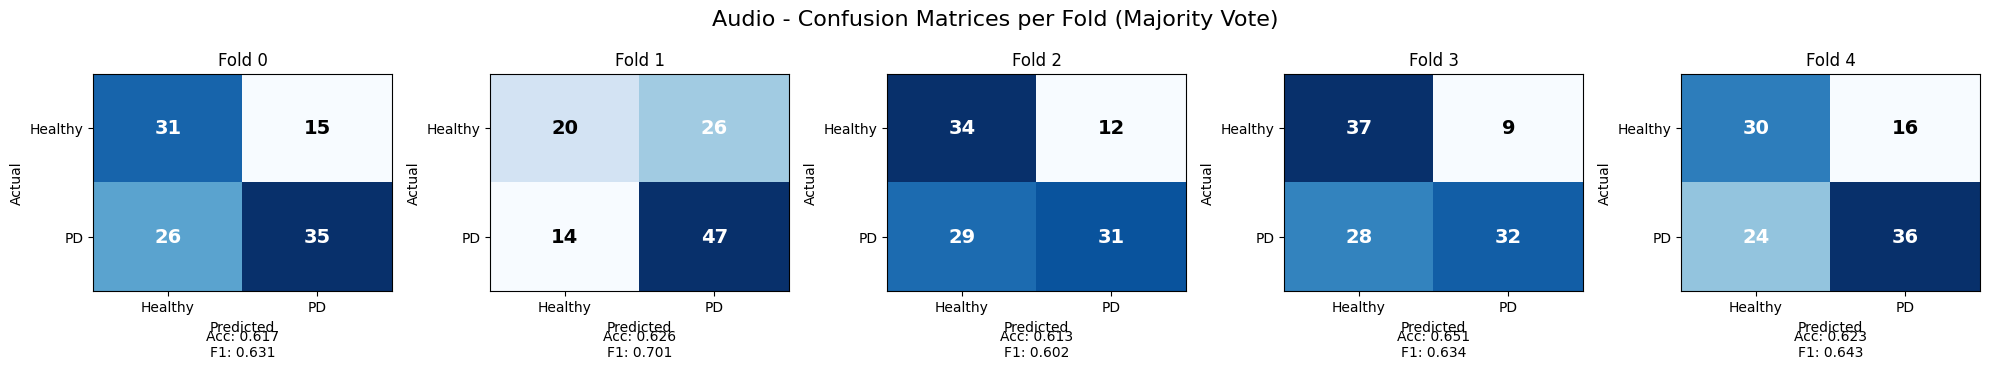


**Overall (Majority Vote) - Audio:**
**Accuracy: 0.6259**
**F1 Score: 0.6453**


In [37]:
# Create a new dataframe with majority voting per healthCode
audio_majority_vote = audio_test_results.groupby(['healthCode', 'fold']).agg({
    'predicted_label': lambda x: stats.mode(x, keepdims=True)[0][0],  # Majority vote
    'actual_label': 'first'  # Should be same for all records of a healthCode
}).reset_index()

print("Audio Majority Vote Results (per HealthCode):")
print(f"Total unique healthCodes: {audio_majority_vote['healthCode'].nunique()}")
print(f"Shape: {audio_majority_vote.shape}\n")

# Plot confusion matrices per fold
fig, axes = plt.subplots(1, 5, figsize=(20, 4))
fig.suptitle('Audio - Confusion Matrices per Fold (Majority Vote)', fontsize=16)

for fold in range(5):
    fold_data = audio_majority_vote[audio_majority_vote['fold'] == fold]
    if len(fold_data) > 0:
        cm = confusion_matrix(fold_data['actual_label'], fold_data['predicted_label'])
        
        # Plot confusion matrix
        im = axes[fold].imshow(cm, cmap='Blues', aspect='auto')
        axes[fold].set_title(f'Fold {fold}')
        axes[fold].set_xlabel('Predicted')
        axes[fold].set_ylabel('Actual')
        axes[fold].set_xticks([0, 1])
        axes[fold].set_yticks([0, 1])
        axes[fold].set_xticklabels(['Healthy', 'PD'])
        axes[fold].set_yticklabels(['Healthy', 'PD'])
        
        # Add text annotations
        for i in range(2):
            for j in range(2):
                text = axes[fold].text(j, i, cm[i, j],
                                      ha="center", va="center", color="white" if cm[i, j] > cm.max()/2 else "black",
                                      fontsize=14, weight='bold')
        
        # Compute metrics
        acc = accuracy_score(fold_data['actual_label'], fold_data['predicted_label'])
        f1 = f1_score(fold_data['actual_label'], fold_data['predicted_label'])
        axes[fold].text(0.5, -0.3, f'Acc: {acc:.3f}\nF1: {f1:.3f}', 
                       ha='center', transform=axes[fold].transAxes, fontsize=10)

plt.tight_layout()
plt.show()

# Overall statistics across folds
all_labels = audio_majority_vote['actual_label'].values
all_preds = audio_majority_vote['predicted_label'].values

overall_acc = accuracy_score(all_labels, all_preds)
overall_f1 = f1_score(all_labels, all_preds)

print(f"\n**Overall (Majority Vote) - Audio:**")
print(f"**Accuracy: {overall_acc:.4f}**")
print(f"**F1 Score: {overall_f1:.4f}**")

## 4. Late Fusion Techniques

Combine predictions from both audio and tapping models using different fusion strategies. Each strategy aggregates the unimodal predictions to produce a final multimodal prediction.

### 4.1 Weighted Average on Probabilities

Combine the class probabilities from both modalities using a weighted average:
1. Average probabilities across trials for each patient and modality
2. Compute weighted combination: `P_fused = w_tapping * P_tapping + w_audio * P_audio`
3. Apply fixed weights optimized for the dataset
4. Predict final label based on threshold (0.5)

This approach leverages the confidence of both models in their predictions.

Combined dataframe shape: (30709, 8)
Modality counts:
modality
tapping    15765
audio      14944
Name: count, dtype: int64

ROC AUC on merged dataframe (before fusion):
  Fold 0 ROC AUC: 0.6350
  Fold 1 ROC AUC: 0.6444
  Fold 2 ROC AUC: 0.7252
  Fold 3 ROC AUC: 0.6492
  Fold 4 ROC AUC: 0.6920
**Mean ROC AUC (before fusion): 0.6691 ± 0.0342**

Using weights: Tapping=1.9, Audio=1
Normalized: T=0.655, A=0.345

Weighted probability dataframe shape: (532, 4)

ROC AUC after weighted averaging (before label prediction):
  Fold 0 ROC AUC: 0.7263
  Fold 1 ROC AUC: 0.7676
  Fold 2 ROC AUC: 0.8167
  Fold 3 ROC AUC: 0.7783
  Fold 4 ROC AUC: 0.7768
**Mean ROC AUC (after fusion): 0.7731 ± 0.0288**

Computing accuracy and F1-score per fold:
  Fold 0 - Accuracy: 0.6822, F1: 0.7119
  Fold 1 - Accuracy: 0.7196, F1: 0.7794
  Fold 2 - Accuracy: 0.7642, F1: 0.7788
  Fold 3 - Accuracy: 0.7264, F1: 0.7603
  Fold 4 - Accuracy: 0.7170, F1: 0.7458

**Mean F1 Score: 0.7552 ± 0.0250**
**Mean Accuracy: 0.7219 ± 0.

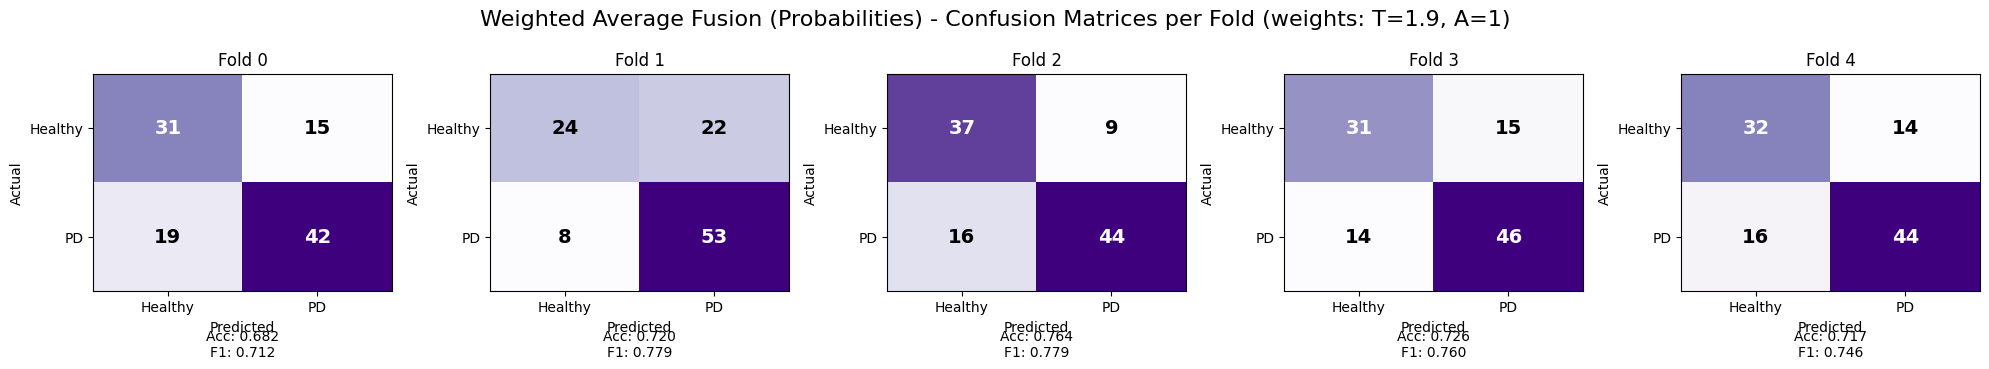


**Weighted Average Fusion (Probabilities) - Final Results:**
**Weights: Tapping=1.9, Audio=1**
**Mean ROC AUC (before fusion): 0.6691 ± 0.0342**
**Mean ROC AUC (after fusion): 0.7731 ± 0.0288**
**Mean F1 Score: 0.7552 ± 0.0250**
**Mean Accuracy: 0.7219 ± 0.0261**


In [38]:
# Add modality column to each dataframe
tapping_with_modality = tapping_test_results.copy()
tapping_with_modality['modality'] = 'tapping'

audio_with_modality = audio_test_results.copy()
audio_with_modality['modality'] = 'audio'

# Concatenate the two dataframes
fusion_proba_df = pd.concat([tapping_with_modality, audio_with_modality], ignore_index=True)

print(f"Combined dataframe shape: {fusion_proba_df.shape}")
print(f"Modality counts:\n{fusion_proba_df['modality'].value_counts()}\n")

# Compute ROC AUC per fold on merged dataframe (before fusion)
print("ROC AUC on merged dataframe (before fusion):")
roc_aucs_before = []
for fold in range(5):
    fold_mask = fusion_proba_df['fold'] == fold
    fold_labels = fusion_proba_df.loc[fold_mask, 'actual_label'].values
    fold_proba = fusion_proba_df.loc[fold_mask, 'proba_class_1'].values
    
    if len(fold_labels) > 0:
        roc_auc = roc_auc_score(fold_labels, fold_proba)
        roc_aucs_before.append(roc_auc)
        print(f"  Fold {fold} ROC AUC: {roc_auc:.4f}")

mean_roc_auc_before = np.mean(roc_aucs_before)
std_roc_auc_before = np.std(roc_aucs_before)
print(f"**Mean ROC AUC (before fusion): {mean_roc_auc_before:.4f} ± {std_roc_auc_before:.4f}**\n")

# Drop predicted_label column
fusion_proba_df = fusion_proba_df.drop(columns=['predicted_label'])

# Set fixed weights
tapping_weight = 1.9
audio_weight = 1

# Normalize weights
total_weight = tapping_weight + audio_weight
norm_tapping_weight = tapping_weight / total_weight
norm_audio_weight = audio_weight / total_weight

print(f"Using weights: Tapping={tapping_weight}, Audio={audio_weight}")
print(f"Normalized: T={norm_tapping_weight:.3f}, A={norm_audio_weight:.3f}\n")

# Compute weighted average probability per healthCode and fold
weighted_proba_results = []

for fold in range(5):
    fold_data = fusion_proba_df[fusion_proba_df['fold'] == fold]
    
    for healthcode in fold_data['healthCode'].unique():
        hc_data = fold_data[fold_data['healthCode'] == healthcode]
        
        # Get probabilities by modality
        tapping_probas = hc_data[hc_data['modality'] == 'tapping']['proba_class_1'].values
        audio_probas = hc_data[hc_data['modality'] == 'audio']['proba_class_1'].values
        
        # Compute weighted average probability
        if len(tapping_probas) > 0 and len(audio_probas) > 0:
            tapping_avg_proba = tapping_probas.mean()
            audio_avg_proba = audio_probas.mean()
            weighted_proba = norm_tapping_weight * tapping_avg_proba + norm_audio_weight * audio_avg_proba
            
            actual_label = hc_data['actual_label'].iloc[0]
            
            weighted_proba_results.append({
                'healthCode': healthcode,
                'fold': fold,
                'weighted_proba_class_1': weighted_proba,
                'actual_label': actual_label
            })

weighted_proba_df = pd.DataFrame(weighted_proba_results)

print(f"Weighted probability dataframe shape: {weighted_proba_df.shape}\n")

# Compute ROC AUC per fold after weighted averaging
print("ROC AUC after weighted averaging (before label prediction):")
roc_aucs_after = []
for fold in range(5):
    fold_data = weighted_proba_df[weighted_proba_df['fold'] == fold]
    if len(fold_data) > 0:
        roc_auc = roc_auc_score(fold_data['actual_label'], fold_data['weighted_proba_class_1'])
        roc_aucs_after.append(roc_auc)
        print(f"  Fold {fold} ROC AUC: {roc_auc:.4f}")

mean_roc_auc_after = np.mean(roc_aucs_after)
std_roc_auc_after = np.std(roc_aucs_after)
print(f"**Mean ROC AUC (after fusion): {mean_roc_auc_after:.4f} ± {std_roc_auc_after:.4f}**\n")

# Predict labels based on threshold 0.5
weighted_proba_df['predicted_label'] = np.where(weighted_proba_df['weighted_proba_class_1'] >= 0.5, 1, 0).astype(int)

# Compute accuracy and F1-score per fold
print("Computing accuracy and F1-score per fold:")
f1_scores = []
accuracies = []

for fold in range(5):
    fold_data = weighted_proba_df[weighted_proba_df['fold'] == fold]
    if len(fold_data) > 0:
        acc = accuracy_score(fold_data['actual_label'], fold_data['predicted_label'])
        f1 = f1_score(fold_data['actual_label'], fold_data['predicted_label'])
        f1_scores.append(f1)
        accuracies.append(acc)
        print(f"  Fold {fold} - Accuracy: {acc:.4f}, F1: {f1:.4f}")

mean_f1 = np.mean(f1_scores)
std_f1 = np.std(f1_scores)
mean_acc = np.mean(accuracies)
std_acc = np.std(accuracies)

print(f"\n**Mean F1 Score: {mean_f1:.4f} ± {std_f1:.4f}**")
print(f"**Mean Accuracy: {mean_acc:.4f} ± {std_acc:.4f}**\n")

# Plot confusion matrices per fold
fig, axes = plt.subplots(1, 5, figsize=(20, 4))
fig.suptitle(f'Weighted Average Fusion (Probabilities) - Confusion Matrices per Fold (weights: T={tapping_weight}, A={audio_weight})', fontsize=16)

for fold in range(5):
    fold_data = weighted_proba_df[weighted_proba_df['fold'] == fold]
    if len(fold_data) > 0:
        cm = confusion_matrix(fold_data['actual_label'], fold_data['predicted_label'])
        
        # Plot confusion matrix
        im = axes[fold].imshow(cm, cmap='Purples', aspect='auto')
        axes[fold].set_title(f'Fold {fold}')
        axes[fold].set_xlabel('Predicted')
        axes[fold].set_ylabel('Actual')
        axes[fold].set_xticks([0, 1])
        axes[fold].set_yticks([0, 1])
        axes[fold].set_xticklabels(['Healthy', 'PD'])
        axes[fold].set_yticklabels(['Healthy', 'PD'])
        
        # Add text annotations
        for i in range(2):
            for j in range(2):
                text = axes[fold].text(j, i, cm[i, j],
                                      ha="center", va="center", color="white" if cm[i, j] > cm.max()/2 else "black",
                                      fontsize=14, weight='bold')
        
        # Compute metrics for display
        acc = accuracy_score(fold_data['actual_label'], fold_data['predicted_label'])
        f1 = f1_score(fold_data['actual_label'], fold_data['predicted_label'])
        axes[fold].text(0.5, -0.3, f'Acc: {acc:.3f}\nF1: {f1:.3f}', 
                       ha='center', transform=axes[fold].transAxes, fontsize=10)

plt.tight_layout()
plt.show()

print(f"\n**Weighted Average Fusion (Probabilities) - Final Results:**")
print(f"**Weights: Tapping={tapping_weight}, Audio={audio_weight}**")
print(f"**Mean ROC AUC (before fusion): {mean_roc_auc_before:.4f} ± {std_roc_auc_before:.4f}**")
print(f"**Mean ROC AUC (after fusion): {mean_roc_auc_after:.4f} ± {std_roc_auc_after:.4f}**")
print(f"**Mean F1 Score: {mean_f1:.4f} ± {std_f1:.4f}**")
print(f"**Mean Accuracy: {mean_acc:.4f} ± {std_acc:.4f}**")


### 4.2 Weighted Average on Predicted Labels

Combine the predicted labels (0 or 1) from both modalities using a weighted average:
1. Average predicted labels across trials for each patient and modality
2. Compute weighted combination of label averages
3. Perform grid search to find optimal weights (maximize F1 score)
4. Apply threshold to determine final prediction

This approach is less sensitive to probability calibration issues.

Combined dataframe shape: (30709, 8)
Modality counts:
modality
tapping    15765
audio      14944
Name: count, dtype: int64

Searching for optimal weights (optimizing for F1 score)...

Best weights found: Tapping=0.60, Audio=0.40
Best mean F1 score: 0.7427



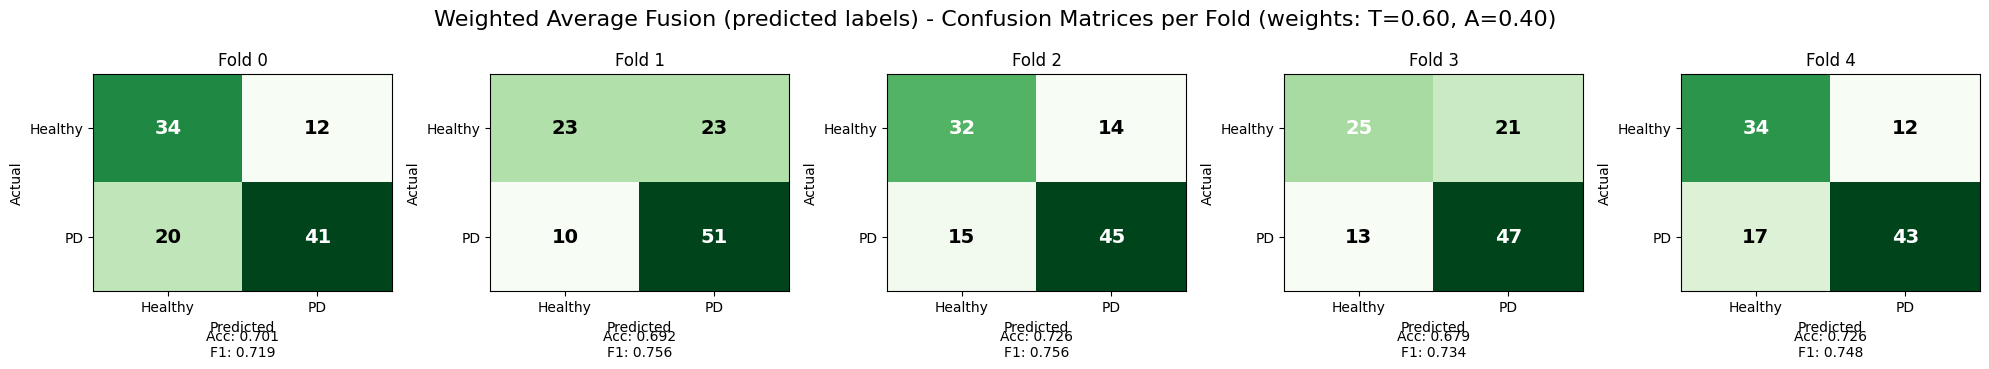


**Weighted Average Fusion Results (Best Weights: T=0.60, A=0.40):**
**Mean F1 Score: 0.7427 ± 0.0141**
**Mean Accuracy: 0.7049 ± 0.0189**


In [39]:
# Add modality column to each dataframe
tapping_with_modality = tapping_test_results.copy()
tapping_with_modality['modality'] = 'tapping'

audio_with_modality = audio_test_results.copy()
audio_with_modality['modality'] = 'audio'

# Concatenate the two dataframes
fusion_df = pd.concat([tapping_with_modality, audio_with_modality], ignore_index=True)

print(f"Combined dataframe shape: {fusion_df.shape}")
print(f"Modality counts:\n{fusion_df['modality'].value_counts()}\n")

# Search for best weights based on F1 score
best_mean_f1 = 0
best_tapping_weight = 0
best_audio_weight = 0
best_mean_acc = 0
best_std_f1 = 0
best_std_acc = 0
best_weighted_avg_df = None

print("Searching for optimal weights (optimizing for F1 score)...")

for x in np.arange(0, 1.01, 0.01):
    tapping_weight = x
    audio_weight = 1 - x
    
    # Compute weighted average per healthCode and fold
    weighted_avg_results = []
    
    for fold in range(5):
        fold_data = fusion_df[fusion_df['fold'] == fold]
        
        for healthcode in fold_data['healthCode'].unique():
            hc_data = fold_data[fold_data['healthCode'] == healthcode]
            
            # Get predictions by modality
            tapping_preds = hc_data[hc_data['modality'] == 'tapping']['predicted_label'].values
            audio_preds = hc_data[hc_data['modality'] == 'audio']['predicted_label'].values
            
            # Compute weighted average
            if len(tapping_preds) > 0 and len(audio_preds) > 0:
                tapping_avg = tapping_preds.mean()
                audio_avg = audio_preds.mean()
                weighted_avg = tapping_weight * tapping_avg + audio_weight * audio_avg
                final_pred = 1 if weighted_avg >= 0.5 else 0
                
                actual_label = hc_data['actual_label'].iloc[0]
                
                weighted_avg_results.append({
                    'healthCode': healthcode,
                    'fold': fold,
                    'predicted_label': final_pred,
                    'actual_label': actual_label,
                    'weighted_avg': weighted_avg
                })
    
    weighted_avg_df = pd.DataFrame(weighted_avg_results)
    
    # Compute metrics for this weight combination
    f1_scores = []
    accuracies = []
    
    for fold in range(5):
        fold_data = weighted_avg_df[weighted_avg_df['fold'] == fold]
        if len(fold_data) > 0:
            acc = accuracy_score(fold_data['actual_label'], fold_data['predicted_label'])
            f1 = f1_score(fold_data['actual_label'], fold_data['predicted_label'])
            f1_scores.append(f1)
            accuracies.append(acc)
    
    mean_f1 = np.mean(f1_scores)
    
    # Update best if this is better (based on F1 score)
    if mean_f1 > best_mean_f1:
        best_mean_f1 = mean_f1
        best_tapping_weight = tapping_weight
        best_audio_weight = audio_weight
        best_mean_acc = np.mean(accuracies)
        best_std_f1 = np.std(f1_scores)
        best_std_acc = np.std(accuracies)
        best_weighted_avg_df = weighted_avg_df.copy()

print(f"\nBest weights found: Tapping={best_tapping_weight:.2f}, Audio={best_audio_weight:.2f}")
print(f"Best mean F1 score: {best_mean_f1:.4f}\n")

# Plot confusion matrices per fold for best weights
fig, axes = plt.subplots(1, 5, figsize=(20, 4))
fig.suptitle(f'Weighted Average Fusion (predicted labels) - Confusion Matrices per Fold (weights: T={best_tapping_weight:.2f}, A={best_audio_weight:.2f})', fontsize=16)

for fold in range(5):
    fold_data = best_weighted_avg_df[best_weighted_avg_df['fold'] == fold]
    if len(fold_data) > 0:
        cm = confusion_matrix(fold_data['actual_label'], fold_data['predicted_label'])
        
        # Plot confusion matrix
        im = axes[fold].imshow(cm, cmap='Greens', aspect='auto')
        axes[fold].set_title(f'Fold {fold}')
        axes[fold].set_xlabel('Predicted')
        axes[fold].set_ylabel('Actual')
        axes[fold].set_xticks([0, 1])
        axes[fold].set_yticks([0, 1])
        axes[fold].set_xticklabels(['Healthy', 'PD'])
        axes[fold].set_yticklabels(['Healthy', 'PD'])
        
        # Add text annotations
        for i in range(2):
            for j in range(2):
                text = axes[fold].text(j, i, cm[i, j],
                                      ha="center", va="center", color="white" if cm[i, j] > cm.max()/2 else "black",
                                      fontsize=14, weight='bold')
        
        # Compute metrics for display
        acc = accuracy_score(fold_data['actual_label'], fold_data['predicted_label'])
        f1 = f1_score(fold_data['actual_label'], fold_data['predicted_label'])
        axes[fold].text(0.5, -0.3, f'Acc: {acc:.3f}\nF1: {f1:.3f}', 
                       ha='center', transform=axes[fold].transAxes, fontsize=10)

plt.tight_layout()
plt.show()

print(f"\n**Weighted Average Fusion Results (Best Weights: T={best_tapping_weight:.2f}, A={best_audio_weight:.2f}):**")
print(f"**Mean F1 Score: {best_mean_f1:.4f} ± {best_std_f1:.4f}**")
print(f"**Mean Accuracy: {best_mean_acc:.4f} ± {best_std_acc:.4f}**")

### 4.3 Majority Voting

Combine predictions using majority voting across all trials from both modalities:
1. Collect all predicted labels from both audio and tapping trials for each patient
2. Take the most frequent prediction (mode) as the final prediction
3. No weighting - each trial contributes equally

This is the simplest fusion approach and is robust to outlier predictions.

Majority Vote Fusion Results:
Total unique healthCodes: 532
Shape: (532, 4)



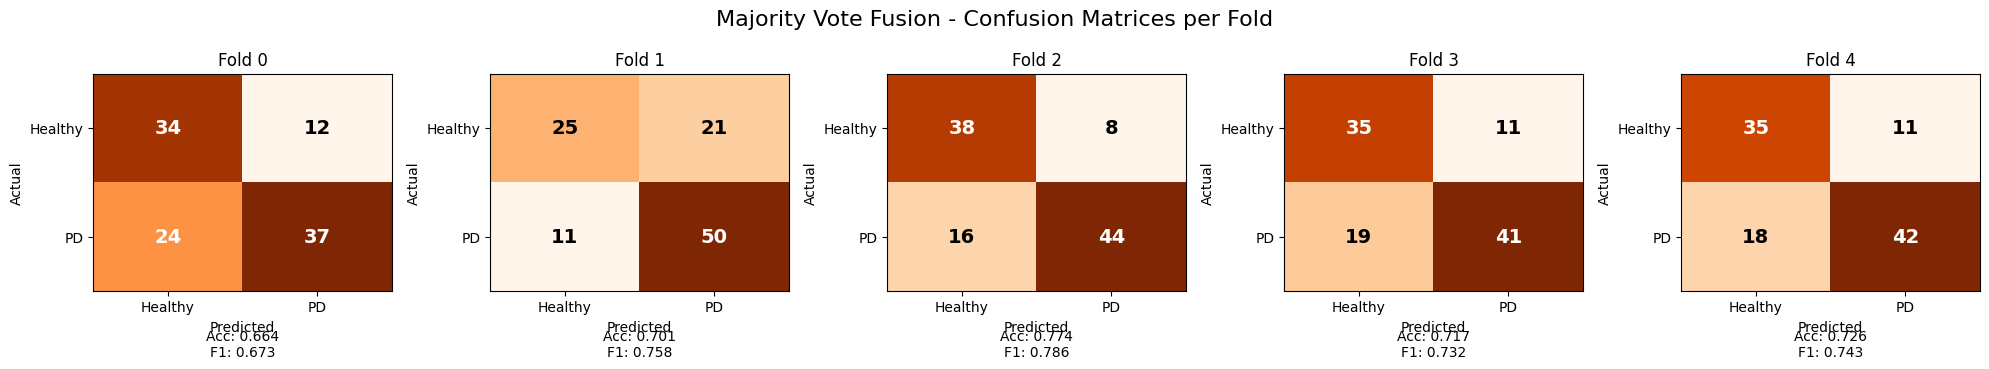


**Majority Vote Fusion Results:**
**Mean F1 Score: 0.7383 ± 0.0374**
**Mean Accuracy: 0.7163 ± 0.0358**


In [40]:
# Use the already concatenated fusion_df from weighted average section
# Or create it again if needed
if 'fusion_df' not in locals():
    tapping_with_modality = tapping_test_results.copy()
    tapping_with_modality['modality'] = 'tapping'
    
    audio_with_modality = audio_test_results.copy()
    audio_with_modality['modality'] = 'audio'
    
    fusion_df = pd.concat([tapping_with_modality, audio_with_modality], ignore_index=True)

# Compute majority voting per healthCode and fold
majority_vote_results = []

for fold in range(5):
    fold_data = fusion_df[fusion_df['fold'] == fold]
    
    for healthcode in fold_data['healthCode'].unique():
        hc_data = fold_data[fold_data['healthCode'] == healthcode]
        
        # Get all predictions for this healthCode (from both modalities)
        all_preds = hc_data['predicted_label'].values
        
        # Majority vote
        majority_pred = stats.mode(all_preds, keepdims=True)[0][0]
        actual_label = hc_data['actual_label'].iloc[0]
        
        majority_vote_results.append({
            'healthCode': healthcode,
            'fold': fold,
            'predicted_label': majority_pred,
            'actual_label': actual_label
        })

majority_vote_df = pd.DataFrame(majority_vote_results)

print(f"Majority Vote Fusion Results:")
print(f"Total unique healthCodes: {majority_vote_df['healthCode'].nunique()}")
print(f"Shape: {majority_vote_df.shape}\n")

# Plot confusion matrices per fold
fig, axes = plt.subplots(1, 5, figsize=(20, 4))
fig.suptitle('Majority Vote Fusion - Confusion Matrices per Fold', fontsize=16)

f1_scores = []
accuracies = []

for fold in range(5):
    fold_data = majority_vote_df[majority_vote_df['fold'] == fold]
    if len(fold_data) > 0:
        cm = confusion_matrix(fold_data['actual_label'], fold_data['predicted_label'])
        
        # Plot confusion matrix
        im = axes[fold].imshow(cm, cmap='Oranges', aspect='auto')
        axes[fold].set_title(f'Fold {fold}')
        axes[fold].set_xlabel('Predicted')
        axes[fold].set_ylabel('Actual')
        axes[fold].set_xticks([0, 1])
        axes[fold].set_yticks([0, 1])
        axes[fold].set_xticklabels(['Healthy', 'PD'])
        axes[fold].set_yticklabels(['Healthy', 'PD'])
        
        # Add text annotations
        for i in range(2):
            for j in range(2):
                text = axes[fold].text(j, i, cm[i, j],
                                      ha="center", va="center", color="white" if cm[i, j] > cm.max()/2 else "black",
                                      fontsize=14, weight='bold')
        
        # Compute metrics
        acc = accuracy_score(fold_data['actual_label'], fold_data['predicted_label'])
        f1 = f1_score(fold_data['actual_label'], fold_data['predicted_label'])
        f1_scores.append(f1)
        accuracies.append(acc)
        axes[fold].text(0.5, -0.3, f'Acc: {acc:.3f}\nF1: {f1:.3f}', 
                       ha='center', transform=axes[fold].transAxes, fontsize=10)

plt.tight_layout()
plt.show()

# Overall statistics
mean_f1 = np.mean(f1_scores)
std_f1 = np.std(f1_scores)
mean_acc = np.mean(accuracies)
std_acc = np.std(accuracies)

print(f"\n**Majority Vote Fusion Results:**")
print(f"**Mean F1 Score: {mean_f1:.4f} ± {std_f1:.4f}**")
print(f"**Mean Accuracy: {mean_acc:.4f} ± {std_acc:.4f}**")